In [6]:
import pandas as pd
import datetime
import numpy as np
from numpy.random import randn
from scipy import stats
import matplotlib as mpl
import matplotlib.dates as md
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# 1. Clean the time series
df = pd.read_csv('CumulativeCases.csv')
df = pd.DataFrame(df).fillna('Nil')
df['Date'] = pd.to_datetime(df['Date'])

df = df.set_index('Date')


In [8]:
# 2. Calculate the measures of central tendencies of your time series
df1 = df[['Belgium', 'Colombia']]
data = df1.copy()
data = data.reset_index().drop('Date', axis=1)
print(data)

xls = df1.describe()
xls.to_excel('Disperse.xlsx')

df = df.reset_index()


     Belgium  Colombia
0          0         0
1          0         0
2          0         0
3          0         0
4          0         0
..       ...       ...
154    59819     45212
155    59918     46858
156    60029     48746
157    60100     50939
158    60155     53063

[159 rows x 2 columns]


In [9]:
# 3. The frequencies of your time series
df1_freq_daily = df1.asfreq('D')
df1_freq_weekly = df1.asfreq('W')
df1_freq_monthly = df1.asfreq('D')
print('Frequency of the time series per day')
print(df1_freq_daily)
print('Frequency of the time series per week')
print(df1_freq_weekly)
print('Frequency of the time series per month')
print(df1_freq_monthly)

Frequency of the time series per day
            Belgium  Colombia
Date                         
2020-01-11        0         0
2020-01-12        0         0
2020-01-13        0         0
2020-01-14        0         0
2020-01-15        0         0
...             ...       ...
2020-06-13    59819     45212
2020-06-14    59918     46858
2020-06-15    60029     48746
2020-06-16    60100     50939
2020-06-17    60155     53063

[159 rows x 2 columns]
Frequency of the time series per week
            Belgium  Colombia
Date                         
2020-01-12        0         0
2020-01-19        0         0
2020-01-26        0         0
2020-02-02        0         0
2020-02-09        1         0
2020-02-16        1         0
2020-02-23        1         0
2020-03-01        1         0
2020-03-08      200         1
2020-03-15      886        24
2020-03-22     2815       196
2020-03-29     9134       539
2020-04-05    18431      1267
2020-04-12    28018      2473
2020-04-19    37183      3439
2

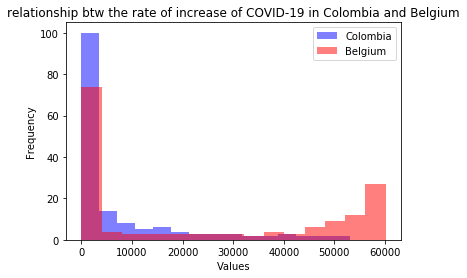

<Figure size 432x288 with 0 Axes>

In [10]:
# 4. Showing a histogram plot & 5. Customizing the histogram
plt.hist(df1['Colombia'], color='blue', bins=15, alpha=0.5, label='Colombia')
plt.hist(df1['Belgium'], color='red', bins=15, alpha=0.5, label='Belgium')
plt.legend()
plt.ylabel('Frequency')
plt.xlabel('Values')
plt.title('relationship btw the rate of increase of COVID-19 in Colombia and Belgium')
plt.show()
plt.savefig('Histogram.png')


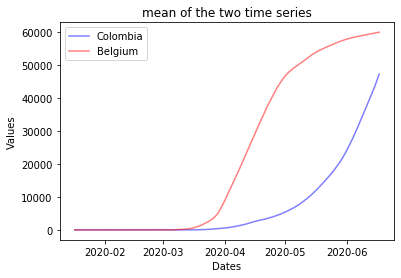

<Figure size 432x288 with 0 Axes>

In [11]:
# for mean window
df1_meancol = df1['Colombia'].rolling(window=7).mean(ddof=0)
df1_meanBel = df1['Belgium'].rolling(window=7).mean(ddof=0)

# 6. Choose best window size to calculate teh average
plt.plot(df1_meancol, color='blue', alpha=0.5, label='Colombia')
plt.plot(df1_meanBel, color='red', alpha=0.5, label='Belgium')
plt.legend()
plt.ylabel('Values')
plt.xlabel('Dates')
plt.title('mean of the two time series')
plt.show()
plt.savefig('mean_window.png')


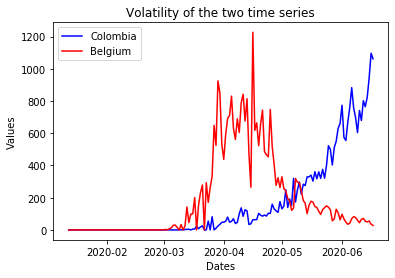

In [12]:
# 7. For Volatility
df1_windcol = df1['Colombia'].rolling(window=2).std(ddof=0)
df1_windBel = df1['Belgium'].rolling(window=2).std(ddof=0)

plt.plot(df1_windcol, color='blue', label='Colombia')
plt.plot(df1_windBel, color='red', label='Belgium')
plt.legend()
plt.ylabel('Values')
plt.xlabel('Dates')
plt.title('Volatility of the two time series')
plt.savefig('Volatility.png')


In [14]:
# 8. write the average anf volatility time series to the csv file
df1['mean_Colomb'] = df1_meancol
df1['mean_Belg'] = df1_meanBel
df1['Volat_Colomb'] = df1_windcol
df1['Volat_Belg'] = df1_windBel
df1.fillna('Nil').to_csv('Volatilities.csv')
print('The Volatilities in .csv file')
print(df1)


The Volatilities in .csv file
            Belgium  Colombia   mean_Colomb     mean_Belg  Volat_Colomb  \
Date                                                                      
2020-01-11        0         0           NaN           NaN           NaN   
2020-01-12        0         0           NaN           NaN           0.0   
2020-01-13        0         0           NaN           NaN           0.0   
2020-01-14        0         0           NaN           NaN           0.0   
2020-01-15        0         0           NaN           NaN           0.0   
...             ...       ...           ...           ...           ...   
2020-06-13    59819     45212  40798.428571  59454.571429         765.0   
2020-06-14    59918     46858  42258.857143  59575.428571         823.0   
2020-06-15    60029     48746  43790.142857  59690.142857         944.0   
2020-06-16    60100     50939  45462.000000  59797.571429        1096.5   
2020-06-17    60155     53063  47225.428571  59900.142857        1062.

C:\Users\LocalAdmin\anaconda3\envs\machinelearning\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y, data. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
C:\Users\LocalAdmin\anaconda3\envs\machinelearning\lib\site-packages\ipykernel_launcher.py:3: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  This is separate from the ipykernel package so we can avoid doing imports until


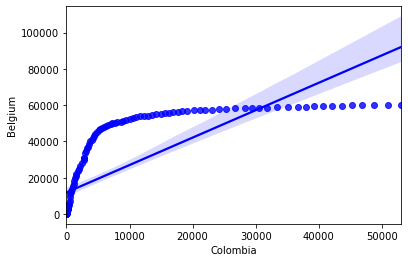

In [30]:
# 9. Regression ananlysis
stack = sns.regplot('Colombia', 'Belgium', data, color='blue', label='p').get_figure()
stack.show()
stack.savefig('Regression.png')